<a href="https://colab.research.google.com/github/yehiamohamed06/Air-Quality-Prediction/blob/main/project_air.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('/content/air_quality_dataset.csv')
data.head()

,Date,City,AQI,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity
0,2024-10-16,Los Angeles,128.0,28.78,68.84,58.29,57.56,2.781,17.10,3.4,82.2
1,2023-01-26,Jacksonville,111.0,28.73,61.93,59.00,35.73,1.810,16.33,17.0,36.0
2,2023-10-09,Houston,91.0,20.04,47.10,66.20,43.91,2.566,15.27,1.0,68.6
3,2023-08-17,Chicago,108.0,23.39,47.90,62.85,48.89,2.332,18.49,9.4,85.7
4,2023-04-15,Austin,106.0,26.51,56.08,62.38,NaN,1.867,15.93,17.3,48.7


EDA & Cleaning

In [3]:
data.shape

(5583, 11)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5583 entries, 0 to 5582
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         5583 non-null   object 
 1   City         5583 non-null   object 
 2   AQI          5472 non-null   float64
 3   PM2.5        5486 non-null   float64
 4   PM10         5523 non-null   float64
 5   Ozone        5508 non-null   float64
 6   NO2          5490 non-null   float64
 7   CO           5421 non-null   float64
 8   SO2          5454 non-null   float64
 9   Temperature  5435 non-null   float64
 10  Humidity     5479 non-null   float64
dtypes: float64(9), object(2)
memory usage: 479.9+ KB


In [5]:
data['Date'] = pd.to_datetime(data['Date'])

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5583 entries, 0 to 5582
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         5583 non-null   datetime64[ns]
 1   City         5583 non-null   object        
 2   AQI          5472 non-null   float64       
 3   PM2.5        5486 non-null   float64       
 4   PM10         5523 non-null   float64       
 5   Ozone        5508 non-null   float64       
 6   NO2          5490 non-null   float64       
 7   CO           5421 non-null   float64       
 8   SO2          5454 non-null   float64       
 9   Temperature  5435 non-null   float64       
 10  Humidity     5479 non-null   float64       
dtypes: datetime64[ns](1), float64(9), object(1)
memory usage: 479.9+ KB


In [7]:
data.isnull().sum()

,0
Date,0
City,0
AQI,111
PM2.5,97
PM10,60
Ozone,75
NO2,93
CO,162
SO2,129
Temperature,148


In [8]:
columns = ['AQI', 'PM2.5', 'PM10', 'Ozone', 'NO2', 'CO', 'SO2', 'Temperature', 'Humidity']
for col in columns: data[col] = data[col].fillna(data[col].median())

In [9]:
data.isnull().sum()

,0
Date,0
City,0
AQI,0
PM2.5,0
PM10,0
Ozone,0
NO2,0
CO,0
SO2,0
Temperature,0


In [10]:
data.duplicated().sum()

np.int64(86)

In [11]:
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

In [12]:
data.describe()

,Date,AQI,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity
count,5497,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000
mean,2024-01-07 12:22:23.860287488,111.979989,26.277470,56.948925,65.782278,43.071997,2.167750,15.774215,14.881917,60.252392
min,2023-01-01 00:00:00,46.000000,9.210000,20.490000,28.350000,22.390000,0.722000,0.000000,-19.700000,8.600000
25%,2023-07-03 00:00:00,97.000000,22.740000,48.470000,54.470000,38.230000,1.860000,13.030000,5.200000,43.000000
50%,2024-01-08 00:00:00,110.000000,25.630000,55.890000,62.990000,42.640000,2.134000,15.550000,14.600000,60.800000
75%,2024-07-12 00:00:00,126.000000,29.030000,64.540000,75.120000,47.210000,2.415000,18.110000,24.600000,78.300000
max,2024-12-30 00:00:00,497.000000,461.330000,448.640000,283.970000,400.990000,47.281000,290.760000,53.500000,100.000000
std,NaN,23.960301,11.746568,15.593627,15.991560,11.039717,1.018871,7.654175,11.648311,21.372079


In [13]:
data['Year'] = data['Date'].dt.year
data.drop(columns=['Date'], inplace=True)

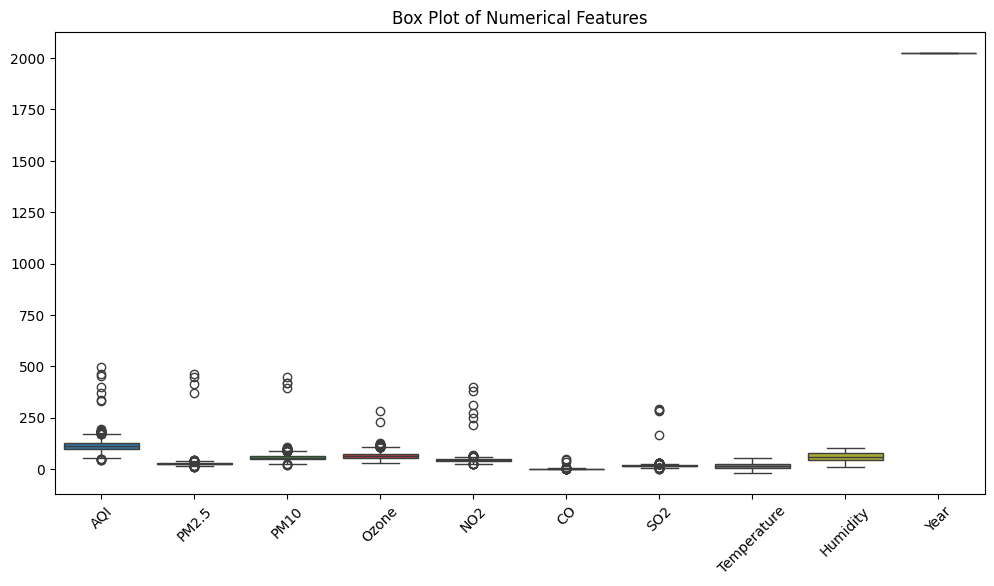

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.title('Box Plot of Numerical Features')
plt.show()

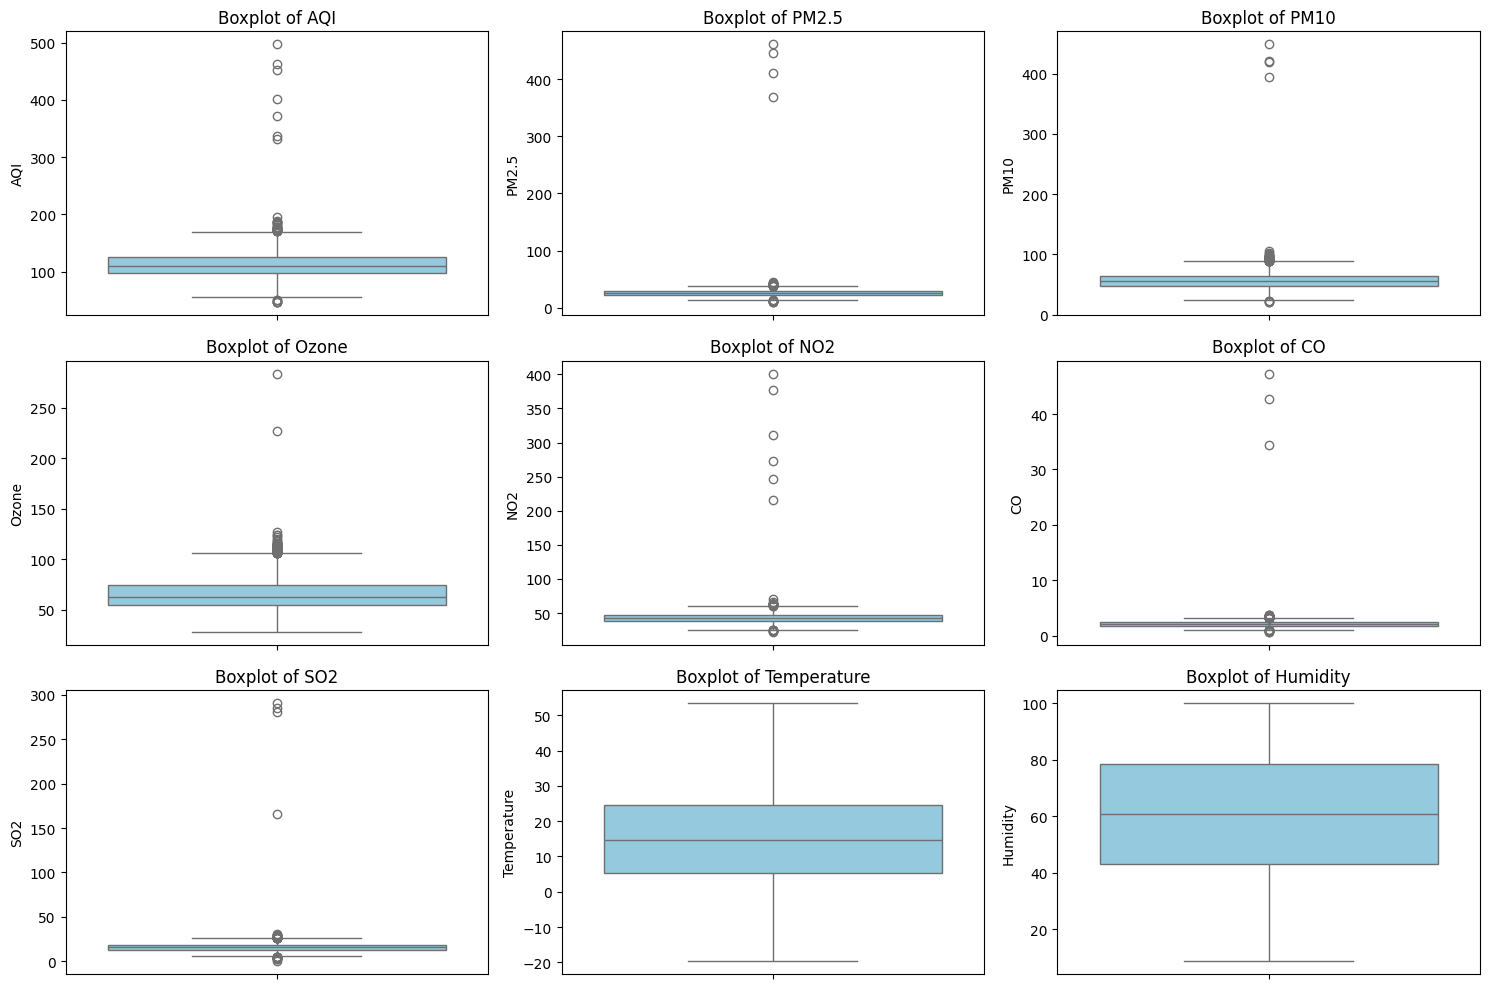

In [15]:
num_cols = ['AQI', 'PM2.5', 'PM10', 'Ozone', 'NO2', 'CO', 'SO2', 'Temperature', 'Humidity']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=data[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [16]:
num_cols = ['AQI','PM2.5', 'PM10', 'Ozone', 'NO2', 'CO', 'SO2', 'Temperature', 'Humidity']

for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])
    data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])

In [17]:
data.describe()

,AQI,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity,Year
count,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000
mean,111.644897,25.990284,56.674843,65.659506,42.799809,2.145958,15.603662,14.881917,60.252392,2023.511006
std,21.372652,4.773321,12.023312,15.387303,6.516851,0.419036,3.807489,11.648311,21.372079,0.499924
min,53.500000,13.305000,24.365000,28.350000,24.760000,1.027500,5.410000,-19.700000,8.600000,2023.000000
25%,97.000000,22.740000,48.470000,54.470000,38.230000,1.860000,13.030000,5.200000,43.000000,2023.000000
50%,110.000000,25.630000,55.890000,62.990000,42.640000,2.134000,15.550000,14.600000,60.800000,2024.000000
75%,126.000000,29.030000,64.540000,75.120000,47.210000,2.415000,18.110000,24.600000,78.300000,2024.000000
max,169.500000,38.465000,88.645000,106.095000,60.680000,3.247500,25.730000,53.500000,100.000000,2024.000000


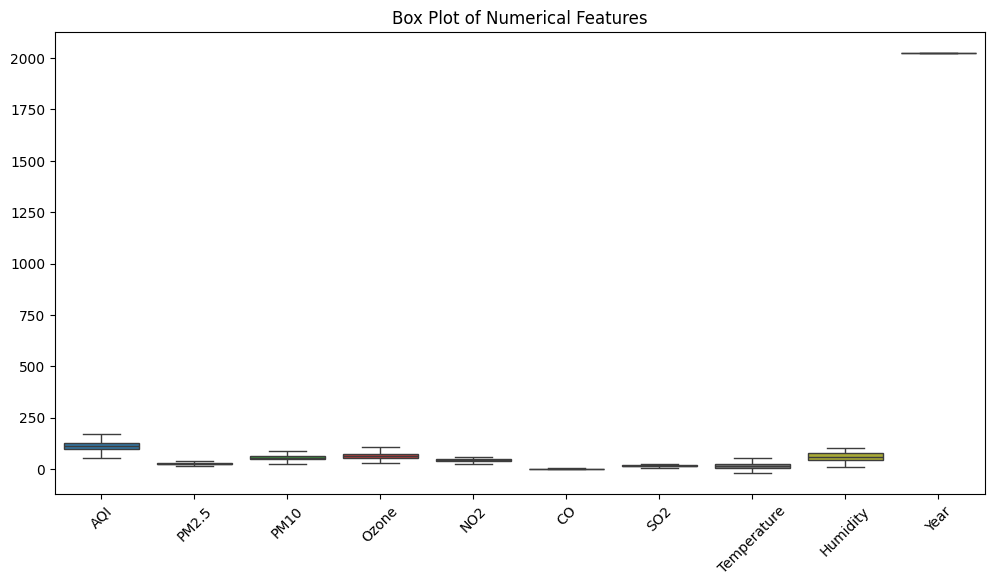

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.title('Box Plot of Numerical Features')
plt.show()

In [19]:
data.describe(include='object')

,City
count,5497
unique,15
top,San Diego
freq,390


In [20]:
data['City'].value_counts()

,count
City,
San Diego,390
Los Angeles,384
Jacksonville,382
San Antonio,381
Austin,376
Fort Worth,368
Columbus,368
San Jose,368
Houston,360


Preprocessing

In [21]:
data.head()

,City,AQI,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity,Year
0,Los Angeles,128.0,28.78,68.84,58.29,57.56,2.781,17.10,3.4,82.2,2024
1,Jacksonville,111.0,28.73,61.93,59.00,35.73,1.810,16.33,17.0,36.0,2023
2,Houston,91.0,20.04,47.10,66.20,43.91,2.566,15.27,1.0,68.6,2023
3,Chicago,108.0,23.39,47.90,62.85,48.89,2.332,18.49,9.4,85.7,2023
4,Austin,106.0,26.51,56.08,62.38,42.64,1.867,15.93,17.3,48.7,2023


In [22]:
data.drop(columns=['Year'], inplace=True)

In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['City'] = le.fit_transform(data['City'])

In [24]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
nums = [ 'PM2.5', 'PM10', 'Ozone', 'NO2', 'CO', 'SO2', 'Temperature', 'Humidity']
data[nums] = scaler.fit_transform(data[nums])

In [25]:
data.head()

,City,AQI,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity
0,8,128.0,0.615064,0.691895,0.385105,0.913140,0.789865,0.575295,0.315574,0.805252
1,7,111.0,0.613076,0.584396,0.394238,0.305401,0.352477,0.537402,0.501366,0.299781
2,6,91.0,0.267687,0.353687,0.486848,0.533129,0.693018,0.485236,0.282787,0.656455
3,2,108.0,0.400835,0.366133,0.443758,0.671771,0.587613,0.643701,0.397541,0.843545
4,0,106.0,0.524841,0.493388,0.437713,0.497773,0.378153,0.517717,0.505464,0.438731


Moduls

In [26]:
x = data.drop(columns=['AQI'])
y = data['AQI']

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [28]:
nums = x.columns.drop('City')
nums

Index(['PM2.5', 'PM10', 'Ozone', 'NO2', 'CO', 'SO2', 'Temperature',
       'Humidity'],
      dtype='object')

In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2 Score): {r2:.4f}")

Mean Absolute Error (MAE): 7.5730
Root Mean Squared Error (RMSE): 9.6757
R-squared (R2 Score): 0.7876


In [31]:
model.fit(X_train_scaled, y_train)

y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"Train Accuracy (R2): {r2_train * 100:.2f}%")
print(f"Test Accuracy (R2): {r2_test * 100:.2f}%")

Train Accuracy (R2): 76.97%
Test Accuracy (R2): 78.76%


In [32]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
X = data.drop(columns=['AQI'])
y = data['AQI']

model.fit(X, y)

LinearRegression()

In [33]:
data.head()

,City,AQI,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity
0,8,128.0,0.615064,0.691895,0.385105,0.913140,0.789865,0.575295,0.315574,0.805252
1,7,111.0,0.613076,0.584396,0.394238,0.305401,0.352477,0.537402,0.501366,0.299781
2,6,91.0,0.267687,0.353687,0.486848,0.533129,0.693018,0.485236,0.282787,0.656455
3,2,108.0,0.400835,0.366133,0.443758,0.671771,0.587613,0.643701,0.397541,0.843545
4,0,106.0,0.524841,0.493388,0.437713,0.497773,0.378153,0.517717,0.505464,0.438731


In [34]:
my_input = np.array([ 5, 0.7 , 0.8 , 0.55 , 0.6  , 0.9 , 0.4, 0.2, 0.3])
model.predict(my_input.reshape(1,-1))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([132.98887801])

In [35]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

models={
    'LR': LinearRegression(),
    'SVM': SVR(),
    'KNN': KNeighborsRegressor(),
    'DT': DecisionTreeRegressor(),
    'RF': RandomForestRegressor(),
    'GB': GradientBoostingRegressor()
}

for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)

  train_r2 = r2_score(y_train, y_pred_train)
  test_r2 = r2_score(y_test, y_pred_test)

  print(f'{name} train R2: {train_r2:.4f}')
  print(f'{name} test R2: {test_r2:.4f}')

LR train R2: 0.7697
LR test R2: 0.7876
SVM train R2: 0.4615
SVM test R2: 0.4615
KNN train R2: 0.8043
KNN test R2: 0.7139
DT train R2: 1.0000
DT test R2: 0.5607
RF train R2: 0.9693
RF test R2: 0.7887
GB train R2: 0.8336
GB test R2: 0.7990


KNN

In [36]:
x = data.drop(columns=['AQI'])
y = data['AQI']

In [37]:
from sklearn.neighbors import KNeighborsRegressor

KNN = KNeighborsRegressor(n_neighbors=5)

KNN.fit(X_train, y_train)

y_pred = KNN.predict(X_test)

In [38]:
KNN.fit(X_train,y_train)

KNeighborsRegressor()

In [39]:
test = np.array([5, 0.7 , 0.8 , 0.55 , 0.6  , 0.9 , 0.4, 0.2, 0.3])
KNN.predict(test.reshape(1,-1))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


array([129.4])

RF

In [40]:
x = data.drop(columns=['AQI'])
y = data['AQI']

In [41]:
from sklearn.ensemble import RandomForestRegressor

RF = RandomForestRegressor()
RF.fit(X_train, y_train)
y_pred_train = RF.predict(X_train)
y_pred_test = RF.score(X_test, y_test)

y_pred_test = RF.predict(X_test)

In [42]:
RF.fit(X_train,y_train)

RandomForestRegressor()

In [43]:
test = np.array([5, 0.7 , 0.8 , 0.55 , 0.6  , 0.9 , 0.4, 0.2, 0.3])
RF.predict(test.reshape(1,-1))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([134.7])

DT

In [44]:
x = data.drop(columns=['AQI'])
y = data['AQI']

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [46]:
nums = x.columns.drop('City')
nums

Index(['PM2.5', 'PM10', 'Ozone', 'NO2', 'CO', 'SO2', 'Temperature',
       'Humidity'],
      dtype='object')

In [47]:
from sklearn.tree import DecisionTreeRegressor

DT = DecisionTreeRegressor()

DT.fit(X_train, y_train)
y_pred_train = RF.predict(X_train)
y_pred_test = RF.score(X_test, y_test)

y_pred_test = DT.predict(X_test)

In [48]:
DT.fit(X_train,y_train)

DecisionTreeRegressor()

In [49]:
test = np.array([5, 0.7 , 0.8 , 0.55 , 0.6  , 0.9 , 0.4, 0.2, 0.3])
DT.predict(test.reshape(1,-1))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([121.])

Infrencing

In [50]:
cols_order = ['City','PM2.5','PM10','Ozone','NO2','CO','SO2','Temperature','Humidity']
input_data = ['Houston', 28.8, 43.5, 61.3, 45.8 ,2.2 , 18.5 ,17.5 ,70.4]

In [51]:
cats = ['City']
nums = ['PM2.5','PM10','Ozone','NO2','CO','SO2','Temperature','Humidity']

In [52]:
input_data = pd.DataFrame([input_data], columns=cols_order)
input_data

,City,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity
0,Houston,28.8,43.5,61.3,45.8,2.2,18.5,17.5,70.4


In [53]:
from sklearn.preprocessing import LabelEncoder
label_encoders = {}

for col in cats:
    le = LabelEncoder()
    input_data[col] = le.fit_transform(input_data[col])
    label_encoders[col] = le

In [54]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
input_data[nums] = scaler.fit_transform(input_data[nums])

In [55]:
prediction = model.predict(input_data)
if prediction == 0:
  print('IQA')


Downloading the models

In [56]:
import pickle
with open('Final_model.pkl', 'wb') as f:
    pickle.dump( models['LR'], f)

In [57]:
scaler = MinMaxScaler()
scaler.fit(X_train)
cols_order = X_train.columns.tolist()

In [58]:
import pickle
nums = ['AQI','PM2.5','PM10','Ozone','NO2','CO','SO2','Temperature','Humidity']
cats = ['City']

with open('model_scaler.pkl', 'wb') as f:
    pickle.dump({
        'scaler': scaler,

        'numeric_cols': nums,
        'binary_cols': cats,
        'feature_order': cols_order
        }, f)